In [1]:
def load_namespace():
    import sys
    sys.path.insert(1,f'/wsu/home/gy/gy40/gy4065/hm_jetscapeml_source')#WSU Grid
    sys.path.insert(1,'/content/drive/My Drive/Projects/110_JetscapeMl/hm_jetscapeml_source')#Colab GDrive v1
    sys.path.insert(1,'/content/drive/MyDrive/Projects/110_JetscapeMl/hm_jetscapeml_source')#Colab GDrive v2
    sys.path.insert(1,f'/mnt/g/My Drive/Projects/110_JetscapeMl/hm_jetscapeml_source')#wsl gdrive
    sys.path.insert(1,'G:\\My Drive\\Projects\\110_JetscapeMl\\hm_jetscapeml_source') #Windows GDrive
    sys.path.insert(1,'/home/arsalan/Projects/110_JetscapeML/hm_jetscapeml_source/') #office tower
    sys.path.insert(1,'/home/arsalan/wsu-grid/hm_jetscapeml_source') #WSU Grid fssh
    
    
load_namespace()

In [2]:
# Loading/Preparing Environment for simulation
from jet_ml.config import Config
#sim main
folds=5
epochs=500
# dataset_size=100000 #10800000 
dataset_size=1800000 

#sim test
# folds=2
# epochs=2
# dataset_size=250


classification_parameter="alpha_s"
q0_value=1.5
constant_parameter=f"q0_{q0_value}"

model_name="mnist_net"
# constant_parameter=None
if constant_parameter!=None:
    model_name=f"{model_name}_{constant_parameter}"
    
batch_size=128
server_name=f"wsu_grid_a100_cpu_16_mem_180gb_batch_{batch_size}"
# server_name=f"wsu_grid_v100_cpu_24_mem_256gb_batch_{batch_size}"
simulation_name=f"{classification_parameter}_{model_name}_{folds}_fold_{epochs}_epoch_{int(dataset_size/1000)}k_dataset_size_{server_name}"

config=Config(simulation_name=simulation_name)
config.__str__()

2024-10-30 13:52:49.694675: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-30 13:52:49.703461: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-30 13:52:49.712764: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-30 13:52:49.715637: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-30 13:52:49.723528: I tensorflow/core/platform/cpu_feature_guar

Directory /home/arsalan/wsu-grid/hm_jetscapeml_source/models/alpha_s_mnist_net_2_fold_2_epoch_1k_dataset_size_wsu_grid_v100_cpu_24_mem_180gb_batch_32 already exists.
Directory /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/alpha_s_mnist_net_2_fold_2_epoch_1k_dataset_size_wsu_grid_v100_cpu_24_mem_180gb_batch_32 already exists.
Directory /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/alpha_s_mnist_net_2_fold_2_epoch_1k_dataset_size_wsu_grid_v100_cpu_24_mem_180gb_batch_32 already exists.


2024-10-30 13:52:50.759880: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


'Project Root: /home/arsalan/wsu-grid/hm_jetscapeml_source\nData Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/data\nModels Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/models\nReports Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports\nFigures Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures\nSimulation Models Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/models/alpha_s_mnist_net_2_fold_2_epoch_1k_dataset_size_wsu_grid_v100_cpu_24_mem_180gb_batch_32\nSimulation Reports Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/alpha_s_mnist_net_2_fold_2_epoch_1k_dataset_size_wsu_grid_v100_cpu_24_mem_180gb_batch_32\nSimulation Figures Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/alpha_s_mnist_net_2_fold_2_epoch_1k_dataset_size_wsu_grid_v100_cpu_24_mem_180gb_batch_32\nEnvironment Details:\n  TensorFlow Version: 2.17.0\n  Keras Version: 3.5.0\n  Python Version: 3.12.5 | packaged by conda-forge | (

In [3]:
from IPython.display import display
# with tf.device("CPU"):
import jet_ml.classifiers.alpha_s.preprocess_dataset as pred
if constant_parameter!=None:
    (x,y_raw,y_df)=pred.preprocess_dataset_for_alpha_s_with_constant_q0(dataset_size,q0=q0_value)
else:
    (x,y_raw,y_df)=pred.preprocess_dataset_for_alpha_s(dataset_size)
y_classes=y_df.columns
y=y_df.values
display("y_classes: ",y_classes)
display("y: ",y[:5])
display("y_raw: ",y_raw[:5])

Dataset Preprocessor
Loading the whole dataset
Extract the working column#1 for classification
dataset.x: <class 'numpy.ndarray'> 1024000 (1000, 32, 32)
dataset.y: <class 'numpy.ndarray'> 1000 (1000,)


'y_classes: '

Index(['0.2', '0.3', '0.4'], dtype='object')

'y: '

array([[1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0]])

'y_raw: '

array(['0.2', '0.2', '0.2', '0.2', '0.2'], dtype='<U32')

In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.mixed_precision import experimental as mixed_precision

# Clear any previous session.
K.clear_session()

# Reset the default graph.
tf.compat.v1.reset_default_graph()

# Enable mixed precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_policy(policy)

# Limit GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

Fold #1
Epoch 1/2


/home/arsalan/miniconda3/envs/tensorflow/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 1: val_loss improved from inf to 1.09777, saving model to /home/arsalan/wsu-grid/hm_jetscapeml_source/models/alpha_s_mnist_net_2_fold_2_epoch_1k_dataset_size_wsu_grid_v100_cpu_24_mem_180gb_batch_32/testnet_fold_1_model.keras
1/1 - 3s - 3s/step - accuracy: 0.3500 - loss: 1.0985 - val_accuracy: 0.3960 - val_loss: 1.0978
Epoch 2/2

Epoch 2: val_loss improved from 1.09777 to 1.09660, saving model to /home/arsalan/wsu-grid/hm_jetscapeml_source/models/alpha_s_mnist_net_2_fold_2_epoch_1k_dataset_size_wsu_grid_v100_cpu_24_mem_180gb_batch_32/testnet_fold_1_model.keras
1/1 - 5s - 5s/step - accuracy: 0.4700 - loss: 1.0959 - val_accuracy: 0.3920 - val_loss: 1.0966
Restoring model weights from the end of the best epoch: 2.
Elpased time: 0:00:08
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Fold score (accuracy): 0.392
training_history_fold_1.csv


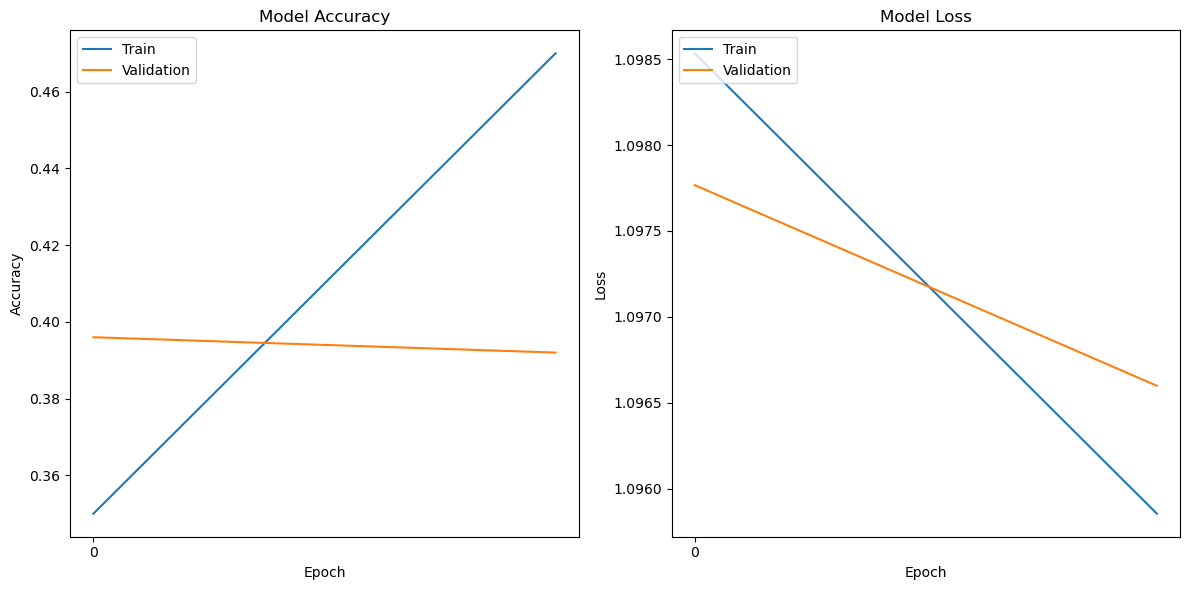

Fold #2
Epoch 1/2


/home/arsalan/miniconda3/envs/tensorflow/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 1: val_loss improved from inf to 1.09778, saving model to /home/arsalan/wsu-grid/hm_jetscapeml_source/models/alpha_s_mnist_net_2_fold_2_epoch_1k_dataset_size_wsu_grid_v100_cpu_24_mem_180gb_batch_32/testnet_fold_2_model.keras
1/1 - 3s - 3s/step - accuracy: 0.3540 - loss: 1.0987 - val_accuracy: 0.3760 - val_loss: 1.0978
Epoch 2/2

Epoch 2: val_loss improved from 1.09778 to 1.09699, saving model to /home/arsalan/wsu-grid/hm_jetscapeml_source/models/alpha_s_mnist_net_2_fold_2_epoch_1k_dataset_size_wsu_grid_v100_cpu_24_mem_180gb_batch_32/testnet_fold_2_model.keras
1/1 - 4s - 4s/step - accuracy: 0.4100 - loss: 1.0964 - val_accuracy: 0.3920 - val_loss: 1.0970
Restoring model weights from the end of the best epoch: 1.
Elpased time: 0:00:06
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold score (accuracy): 0.376
training_history_fold_2.csv


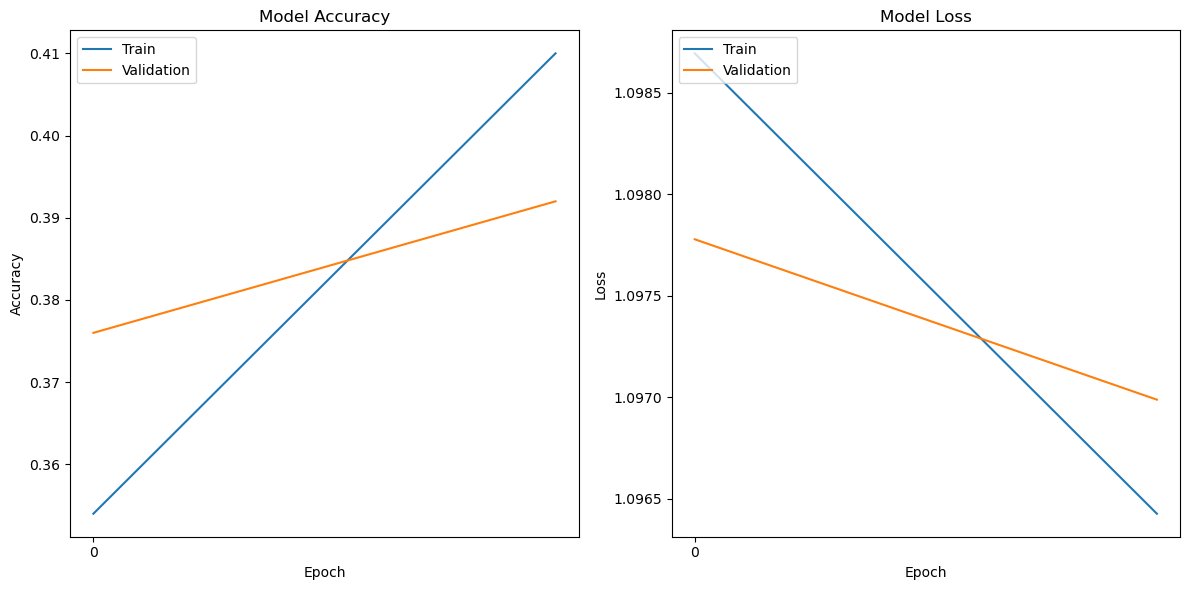

stored all splits' history in training_stats.csv


In [5]:

from jet_ml.models.mnist_net import build_model
from jet_ml.models.helpers import compile_model
from jet_ml.models.mnist_net import train_model
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn import metrics
k_fold=StratifiedKFold(folds,shuffle=True,random_state=42)

out_of_sample_y=[]
out_of_sample_pred=[]
fold=0
folds_accuracy=[]
epochs_needed = []
times_taken=[]
batch_size=32
#Must specify y StratifiedKFold for classification
for train,test in k_fold.split(x,y_raw):
    fold+=1
    print(f"Fold #{fold}")

    x_train=x[train]
    y_train=y[train]
    x_test=x[test]
    y_test=y[test]

    
    input_shape=x[0].shape
    output_shape=y.shape[1]
    activation='softmax'
    model=build_model(input_shape,output_shape,activation)
    
    model=compile_model(model)
    monitor='val_accuracy' #'val_accuracy' or 'val_loss'

    model, history,elapsed_time,stopped_epoch=train_model(model,
                                        x_train,y_train, x_test,y_test, 
                                        epochs, batch_size, monitor,
                                        fold=fold)
    
    from jet_ml.evaluation import get_accuracy
    pred, score=get_accuracy(model,x_test=x_test,y_test=y_test)

    folds_accuracy.append(score)
    times_taken.append(elapsed_time)    
    epochs_needed.append(epochs)

    out_of_sample_y.append(y_test)
    out_of_sample_pred.append(pred)
    print(f"Fold score (accuracy): {score}")

    from jet_ml.evaluation import save_training_history
    save_training_history(history=history,fold=fold)

    from jet_ml.evaluation import plot_training_history
    plot_training_history(history=history,fold=fold)


from jet_ml.evaluation import save_training_stats
save_training_stats(accuracies=folds_accuracy,
                    epochs_needed=epochs_needed,
                    times_taken=times_taken)

# Build the oos prediction list and calculate the error.
out_of_sample_y=np.concatenate(out_of_sample_y)
out_of_sample_pred=np.concatenate(out_of_sample_pred)

out_of_sample_y_compare=np.argmax(out_of_sample_y,axis=1)# For accuracy and confusion matrix calculation

In [6]:
from jet_ml.evaluation import calculate_accuracy
calculate_accuracy(out_of_sample_y_compare,out_of_sample_pred)

'accuracy: 0.384'

In [7]:
from jet_ml.evaluation import store_out_of_sample_y_and_predictions
store_out_of_sample_y_and_predictions(y_df,out_of_sample_y,out_of_sample_pred,y_classes)

Confusion matrix, without normalization
[[ 65  22 248]
 [ 46  32 255]
 [ 27  18 287]]
Normalized confusion matrix
[[0.19 0.07 0.74]
 [0.14 0.1  0.77]
 [0.08 0.05 0.86]]


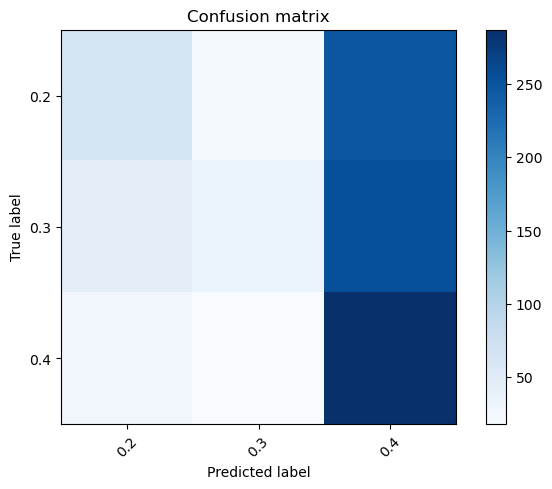

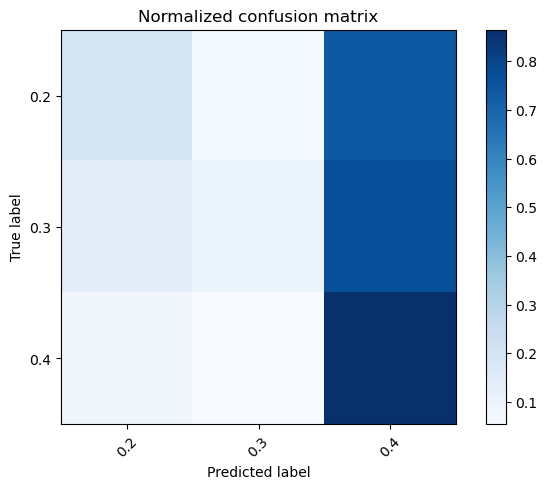

In [8]:
from jet_ml.evaluation import calculate_confusion_matrix
calculate_confusion_matrix(out_of_sample_y_compare, out_of_sample_pred,y_classes)